In [1]:
import pandas as pd 

In [2]:
# Đọc dữ liệu
true_data = pd.read_csv('News _dataset/True.csv')  # Tin thật
fake_data = pd.read_csv('News _dataset/Fake.csv')  # Tin giả

In [3]:
# Thêm cột nhãn
true_data['label'] = 1  # 1: Tin thật
fake_data['label'] = 0  # 0: Tin giả

In [4]:
data = pd.concat([true_data, fake_data], axis=0).reset_index(drop=True)

In [5]:
print(data.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       1  
1  December 29, 2017       1  
2  December 31, 2017       1  
3  December 30, 2017       1  
4  December 29, 2017       1  


In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
lemmatizer = WordNetLemmatizer()

In [8]:
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  # Loại bỏ dấu câu
    text = re.sub(r'\d+', '', text)      # Loại bỏ số
    text = text.lower()                  # Chuyển về chữ thường
    words = word_tokenize(text)          # Tokenize
    words = [word for word in words if word not in stop_words]  # Loại bỏ stop words
    words = [lemmatizer.lemmatize(word) for word in words]  # Lematize các từ
    return words

In [9]:
data['processed_text'] = data['text'].apply(preprocess_text)  # Giả sử cột chứa văn bản là 'text'

In [10]:
preprocess_text('The quick brown fox jumps over the lazy dog')

['quick', 'brown', 'fox', 'jump', 'lazy', 'dog']

In [11]:
from gensim.models import Word2Vec

In [12]:
sentences = data['processed_text']
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

In [13]:
word2vec_model.save('word2vec_model.bin')

In [14]:
import numpy as np
# Chuyển văn bản thành vector trung bình của các từ trong văn bản
def get_average_word2vec(words, word2vec_model):
    vec = []
    for word in words:
        if word in word2vec_model.wv:
            vec.append(word2vec_model.wv[word])
    # Nếu có vector, tính trung bình, nếu không thì trả về vector toàn số 0
    return np.mean(vec, axis=0) + np.abs(np.min(vec)) if vec else np.zeros(word2vec_model.vector_size)

In [15]:
# Tạo đặc trưng vector cho mỗi bài báo
X = [get_average_word2vec(text, word2vec_model) for text in data['processed_text']]
y = data['label']
X

[array([ 8.969109 ,  8.481881 ,  7.857249 ,  9.195559 ,  8.4741745,
         8.70021  ,  7.89105  ,  8.029789 ,  8.629573 ,  8.658763 ,
         8.861289 ,  8.475619 , 10.066681 ,  8.582661 ,  8.23943  ,
         8.469065 ,  8.502551 ,  8.196767 ,  8.357976 ,  9.819542 ,
         9.321237 ,  8.131502 ,  8.23942  ,  8.541725 ,  9.147842 ,
         8.237488 ,  8.6894455,  8.926215 ,  9.250803 ,  8.157281 ,
         8.189719 ,  8.787653 ,  8.355392 ,  8.9276905,  8.455951 ,
         8.724999 ,  9.368517 ,  8.950772 ,  7.6191297,  9.045055 ,
         8.719299 ,  7.607376 ,  9.161647 ,  7.783533 ,  7.770852 ,
         8.508826 ,  7.624558 ,  9.504199 ,  8.661512 ,  8.877235 ,
         7.6434174,  8.263868 ,  8.649626 ,  8.779811 ,  8.242013 ,
         9.13338  ,  8.486641 ,  8.339723 ,  8.223513 ,  8.426563 ,
         8.501739 ,  8.77557  ,  7.53759  ,  8.665613 ,  7.8437667,
         7.301723 ,  8.433505 ,  7.9030876,  9.43897  ,  9.109975 ,
         8.227904 ,  7.260469 ,  8.598038 ,  8.2

In [16]:
from sklearn.model_selection import train_test_split
# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.naive_bayes import MultinomialNB
# Huấn luyện mô hình Naive Bayes
model = MultinomialNB()
history = model.fit(X_train, y_train)

In [18]:
from sklearn.metrics import accuracy_score

In [19]:
# Dự đoán nhãn trên tập kiểm tra
y_pred = model.predict(X_test)

# Tính toán độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.14%


In [20]:
def check_fake_news(text, word2vec_model, model):
    processed_text = preprocess_text(text)  # Tiền xử lý văn bản
    text_vector = get_average_word2vec(processed_text, word2vec_model)  # Tạo vector trung bình
    text_vector = text_vector.reshape(1, -1)  # Đảm bảo là mảng 2 chiều
    prediction = model.predict(text_vector)  # Dự đoán
    return "Fake News" if prediction[0] == 1 else "True News"


In [21]:
# Ví dụ dự đoán
new_text = "The following statements were posted to the verified Twitter accounts of U.S. President Donald Trump, @realDonaldTrump and @POTUS.  The opinions expressed are his own. Reuters has not edited the statements or confirmed their accuracy.  @realDonaldTrump : - Based on the fact that the very unfair and unpopular Individual Mandate has been terminated as part of our Tax Cut Bill, which essentially Repeals (over time) ObamaCare, the Democrats & Republicans will eventually come together and develop a great new HealthCare plan! [0658 EST] - WOW, @foxandfrlends “Dossier is bogus. Clinton Campaign, DNC funded Dossier. FBI CANNOT (after all of this time) VERIFY CLAIMS IN DOSSIER OF RUSSIA/TRUMP COLLUSION. FBI TAINTED.” And they used this Crooked Hillary pile of garbage as the basis for going after the Trump Campaign! [0824 EST] - All signs are that business is looking really good for next year, only to be helped further by our Tax Cut Bill. Will be a great year for Companies and JOBS! Stock Market is poised for another year of SUCCESS! [17:17 EST] -- Source link: (bit.ly/2jBh4LU) (bit.ly/2jpEXYR)"
result = check_fake_news(new_text, word2vec_model, model)
print(f"Đoạn văn bản là: {result}")

Đoạn văn bản là: True News


In [22]:
import joblib
# Lưu mô hình Naive Bayes
joblib.dump(model, 'naive_bayes_model_using_Word2Vec.pkl')

['naive_bayes_model_using_Word2Vec.pkl']

In [23]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# # Dự đoán nhãn của tập kiểm tra
# y_pred = model.predict(X_test)
# y_pred = (y_pred > 0.5).astype(int).flatten()  # Chuyển kết quả dự đoán thành nhãn 0 hoặc 1

# Tính toán các chỉ số đánh giá
print("Classification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      4650
           1       0.92      0.78      0.84      4330

    accuracy                           0.86      8980
   macro avg       0.87      0.86      0.86      8980
weighted avg       0.87      0.86      0.86      8980

Accuracy: 0.86
Precision: 0.92
Recall: 0.78
F1 Score: 0.84


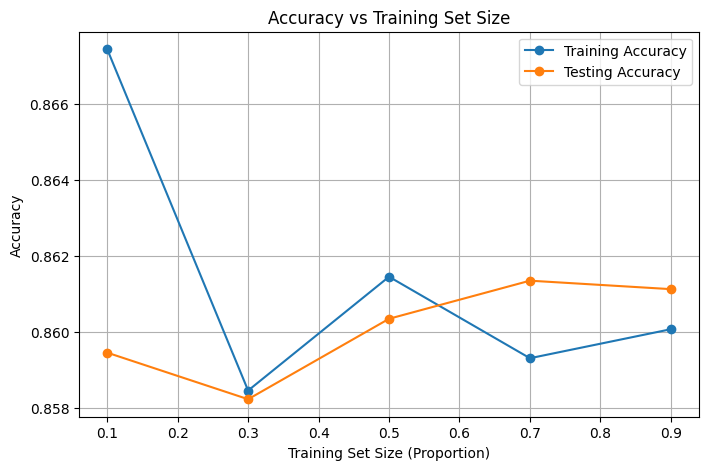

In [26]:
train_sizes = [0.1, 0.3, 0.5, 0.7, 0.9]
train_accuracies = []
test_accuracies = []

for size in train_sizes:
    X_partial, _, y_partial, _ = train_test_split(X_train, y_train, train_size=size, random_state=42)
    model = MultinomialNB()
    model.fit(X_partial, y_partial)

    # Độ chính xác trên tập huấn luyện và kiểm tra
    train_acc = accuracy_score(y_partial, model.predict(X_partial))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_accuracies, marker='o', label='Testing Accuracy')
plt.title('Accuracy vs Training Set Size')
plt.xlabel('Training Set Size (Proportion)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
